In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

def celeridad(h, T):
  tol=1e-4
  max_iter=100

  omega = (2*np.pi)/T

  def fenton_mckee(h, omega):
    y = (omega**2) * h / g
    y_34 = y ** 0.75
    coth_y34 = 1 / np.tanh(y_34)
    xi = y * (coth_y34 ** (2/3))
    return xi

  def ecuacion_dispersion(h, omega, xi):
    primer_termino = (omega**2) * (h/g)
    segundo_termino = xi * np.tanh(xi)
    return primer_termino - segundo_termino

  def ecuacion_dispersion_derivada(h, omega, xi):
    cos_hip = np.cosh(xi)
    denominador_primer_termino= cos_hip**2
    primer_termino = (xi/denominador_primer_termino)
    segundo_termino = np.tanh(xi)
    return -primer_termino -segundo_termino

  xi = fenton_mckee(h, omega)

  for i in range(max_iter):
    f = ecuacion_dispersion(h, omega, xi)
    df = ecuacion_dispersion_derivada(h, omega, xi)
    x_nuevo = xi - (f / df)
    if abs(x_nuevo - xi) < tol:
      break
    xi = x_nuevo

  k = xi / h
  L = 2 * np.pi / k
  C = L/T

  return C

#funciones extra para calcular las propieades de la ola

def factor_n(C, h):
  k = (2 * np.pi / T*C)
  numerador = 2*k*h
  denominador = np.sinh(2*k*h)
  return (1 + (numerador / denominador))*0.5

def cg(C, n):
  return C*n

def celeridad_xy(x, y):
    h = batimetria(x, y)
    return celeridad(h, T)

def celeridad_yx(y, x):
    h = batimetria(x, y)
    return celeridad(h, T)

#funciones de derivadas para no tener que repetirlas en el código

def df_primera_derivada(f, x, y, h):
  return (f(x + h, y) - f(x - h, y)) / (2*h)

def df_segunda_derivada(f, x, y, h):
  return (f(x + h, y) - 2*f(x, y) + f(x - h, y)) / (h**2)

def df_mixta_derivada(f, x, y, dx, dy):
    f_pp = f(x + dx, y + dy)
    f_pm = f(x + dx, y - dy)
    f_mp = f(x - dx, y + dy)
    f_mm = f(x - dx, y - dy)
    derivada = (f_pp - f_pm - f_mp + f_mm) / (4 * dx * dy)
    return derivada

# función batimetría q aparece en el gráfico del libro

def batimetria(x, y):
    primer_termino = 0.025 * x
    exponente = -3 * (x / 20)**(1/3)
    termino_exp = 20 * np.exp(exponente)
    termino_seno = np.sin(np.pi * y / 80)**10
    segundo_termino = 1 + termino_exp * termino_seno
    profundidad = primer_termino * segundo_termino

    return profundidad

# la funcion principal que queremos resolver, variable independiente (tiempo) y dependiente iniciales

def funcion_ray_tracing(t, y_inicial):

  # variables dependientes [x, y, theta, beta, sigma]

  #calculos iniciales
  x = y_inicial[0]
  y = y_inicial[1]
  theta = y_inicial[2]
  beta = y_inicial[3]
  sigma = y_inicial[4]

  h = batimetria(x, y)
  C = celeridad(h, T)

  #calculo de diferencias finitas
  dx = 0.1
  dy = 0.1
  #f de celeridad depende de f de batimetria, la cual depende de (x,y)
  dC_dx = df_primera_derivada(celeridad_xy, x, y, dx)
  dC_dy = df_primera_derivada(celeridad_yx, y, x, dy)
  d2C_d2y = df_segunda_derivada(celeridad_yx, y, x, dy)
  d2C_d2x = df_segunda_derivada(celeridad_xy, x, y, dx)
  d2C_dxy = df_mixta_derivada(celeridad_xy, x, y, dx, dy)

  #calculo de variables de soporte
  p = -np.cos(theta)*dC_dx - np.sin(theta)*dC_dy
  q = (np.sin(theta)**2)*d2C_d2x - 2*np.sin(theta)*np.cos(theta)*d2C_dxy + (np.cos(theta)**2)*d2C_d2y

  #calculo de EDOs
  f_velocidad_x = C*np.cos(theta)
  f_velocidad_y = C*np.sin(theta)
  f_tasa_theta = np.sin(theta)*dC_dx - np.cos(theta)*dC_dy
  f_tasa_sigma = C*sigma
  f_tasa_beta = -p*sigma - q*beta

  #fin

  return np.array([f_velocidad_x, f_velocidad_y, f_tasa_theta, f_tasa_beta, f_tasa_sigma])

# el metodo runge kuta4

def rk4(f, xi, yi, h):
  k1 = f(xi, yi)
  k2 = f(xi + 0.5*h, yi + 0.5*k1*h)
  k3 = f(xi + 0.5*h, yi + 0.5*k2*h)
  k4 = f(xi + h, yi + k3*h)
  return yi + (1/6)*(k1 + 2*k2 + 2*k3 + k4)*h

# El solver de la función usando rk4

def calcular_parametros(f, t, y, dt):
  t_lista = []
  y_lista = []
  while t <= t_final and y[0]>1:
    t_lista.append(t)
    y_lista.append(y)
    y = rk4(funcion_ray_tracing, t, y, dt)
    t += dt

  return np.array(t_lista), np.array(y_lista)

# funcion que calcula las alturas para el rayo obtenido del solver

def altura_olas(y_array_calculado, y_array_inicial, altura_inicial):
    x_inicial = y_array_inicial[0]
    y_inicial = y_array_inicial[1]
    batimetria_inicial = batimetria(x_inicial, y_inicial)
    c_inicial = celeridad(batimetria_inicial, T)
    n_inicial = factor_n(c_inicial, batimetria_inicial)
    cg_inicial = cg(c_inicial, n_inicial)


    coordenadas_x = y_array_calculado[:, 0]
    coordenadas_y = y_array_calculado[:, 1]
    array_beta = y_array_calculado[:, 3]
    array_batimetria_rayo = batimetria(coordenadas_x, coordenadas_y)
    array_celeridad_rayo = np.array([celeridad(h, T) for h in array_batimetria_rayo])
    array_n_rayo = factor_n(array_celeridad_rayo, array_batimetria_rayo)
    array_celeridad_grupo_rayo = cg(array_celeridad_rayo, array_n_rayo)
    array_alturas_rayo = altura_inicial*np.sqrt(cg_inicial/array_celeridad_grupo_rayo)*(1/np.sqrt(array_beta))

    return array_alturas_rayo


t_inicial = 0
H_inicial = 1 # [m]
T = 4 #[s]
H_inicial = 1 #[m]
valor_inicial = np.array([200, 65, np.radians(153), 1, 0]) # [x, y, theta, beta, sigma]
t_final = 100 # [s]
t_paso = 0.1
g = 9.81

valor_inicial_1 = np.array([200, 80, np.radians(153), 1, 0]) # [x, y, theta, beta, sigma]
valor_inicial_2 = np.array([200, 65, np.radians(153), 1, 0]) # [x, y, theta, beta, sigma]
valor_inicial_3 = np.array([200, 80, np.radians(180), 1, 0]) # [x, y, theta, beta, sigma]
valor_inicial_4 = np.array([200, 2, np.radians(153), 1, 0]) # [x, y, theta, beta, sigma]

t_array = calcular_parametros(funcion_ray_tracing, t_inicial, valor_inicial_1, t_paso)[0]
y_array_1 = calcular_parametros(funcion_ray_tracing, t_inicial, valor_inicial_1, t_paso)[1]
y_array_2 = calcular_parametros(funcion_ray_tracing, t_inicial, valor_inicial_2, t_paso)[1]
y_array_3 = calcular_parametros(funcion_ray_tracing, t_inicial, valor_inicial_3, t_paso)[1]
y_array_4 = calcular_parametros(funcion_ray_tracing, t_inicial, valor_inicial_4, t_paso)[1]

x_lim = np.linspace(0, 200, 400)
y_lim = np.linspace(-10, 160, 400)
X, Y = np.meshgrid(x_lim, y_lim)
Z = batimetria(X, Y)
niveles = np.arange(0.5, 5.0, 0.5)


rayos = []
alturas = []
for y in range(-150, 200, 10):
  valor_inicial = np.array([200, y, np.radians(153), 1, 0])
  y_array = calcular_parametros(funcion_ray_tracing, t_inicial, valor_inicial, t_paso)[1]
  alturas.append(altura_olas(y_array, valor_inicial, H_inicial))
  rayos.append(y_array)



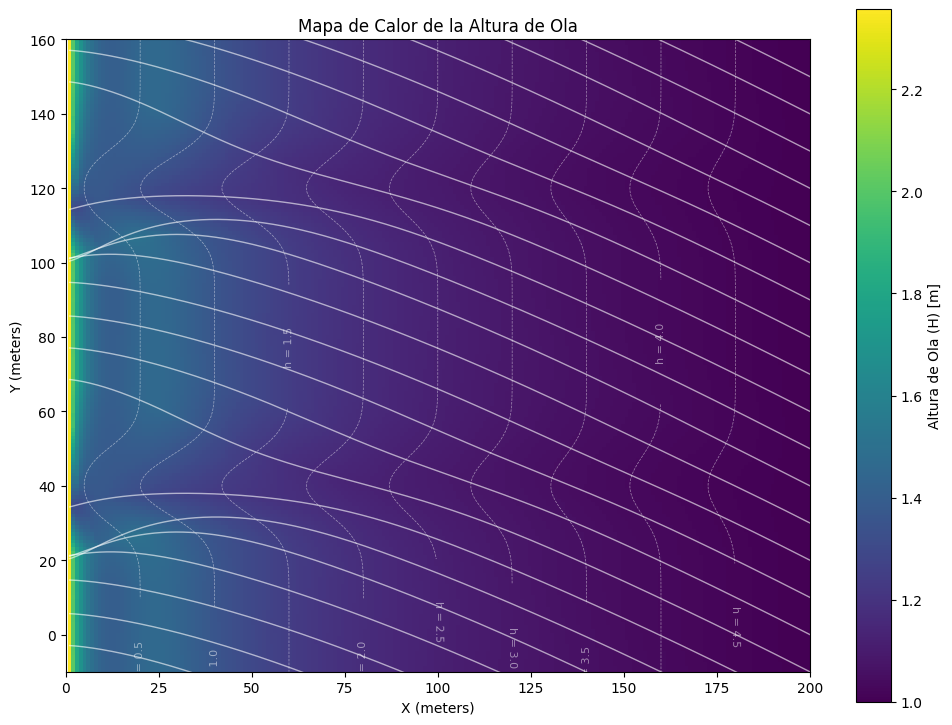

In [3]:
puntos_x_dispersos = np.concatenate([rayo[:, 0] for rayo in rayos])
puntos_y_dispersos = np.concatenate([rayo[:, 1] for rayo in rayos])
valores_h_dispersos = np.concatenate(alturas)


puntos_xy = np.vstack((puntos_x_dispersos, puntos_y_dispersos)).T


x_grilla = np.linspace(0, 200, 200)
y_grilla = np.linspace(-10, 160, 171)
X_grilla, Y_grilla = np.meshgrid(x_grilla, y_grilla)


H_interpolado = griddata(puntos_xy, valores_h_dispersos, (X_grilla, Y_grilla), method='linear', fill_value=np.nan)


fig, ax = plt.subplots(figsize=(12, 9))
mapa_calor = ax.pcolormesh(X_grilla, Y_grilla, H_interpolado, cmap='viridis', shading='auto')
fig.colorbar(mapa_calor, ax=ax, label='Altura de Ola (H) [m]')

for rayo in rayos:
    ax.plot(rayo[:, 0], rayo[:, 1], color='white', linewidth=1, alpha=0.6)

ax.set_xlabel('X (meters)')
ax.set_ylabel('Y (meters)')
contornos = ax.contour(X, Y, Z, levels=niveles, colors='white', linestyles='dashed', linewidths=0.5, alpha=0.5)
ax.clabel(contornos, inline=True, fontsize=8, fmt='h = %1.1f')
ax.set_title('Mapa de Calor de la Altura de Ola')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, 200)
ax.set_ylim(-10, 160)

plt.show()
